In [ ]:
!pip install -r requirements.txt


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SK

# 1. Entendimento do Negócio (Business Understanding)

## 1.1 Contexto do Problema

Reincidência criminal é um desafio crítico do sistema de justiça criminal. A capacidade de prever com precisão quais indivíduos têm maior probabilidade de recindir após libertação é essencial para:

- **Alocação de recursos**: Direcionar programas de reabilitação e supervisão para indivíduos de alto risco
- **Tomada de decisões judiciais**: Auxiliar em decisões de condicional, liberdade supervisionada e prisão preventiva
- **Redução de crimes**: Minimizar danos à comunidade através de intervenções direcionadas
- **Equidade no sistema**: Identificar fatores que influenciam reincidência e possíveis vieses

## 1.2 Pergunta de Negócio

**Quais características demográficas, penais e comportamentais são mais indicativas de reincidência criminal nos 3 anos seguintes à libertação?**

## 1.3 Objetivos do Projeto

### Objetivo Principal
Desenvolver um modelo preditivo que identifique indivíduos com alto risco de reincidência nos 3 anos seguintes à libertação, com acurácia e recall balanceados.

### Objetivos Secundários
1. Identificar os fatores mais influentes na reincidência
2. Criar um sistema de classificação de risco (alto/baixo) para facilitar o uso prático
3. Avaliar a performance do modelo em dados históricos
4. Documentar insights acionáveis para políticas de justiça criminal

## 1.4 Definição Operacional da Variável Alvo

**Reincidência Criminal**: Prisão comprovada dentro de 3 anos após a libertação inicial

- **Classe Positiva (1)**: Indivíduo reincidiu (foi preso novamente)
- **Classe Negativa (0)**: Indivíduo não reincidiu

## 1.5 Dataset e Dados Disponíveis

**Fonte**: NIJ (National Institute of Justice) Challenge 2021
- **Período**: Dados históricos de detentos e suas trajetórias
- **Tamanho**: ~25.000 registros
- **Features**: 54 variáveis (demográficas, histórico penal, comportamento, etc.)

### Tipos de Dados Disponíveis
- **Demográficos**: Idade, gênero, raça, estado civil
- **Histórico Penal**: Crimes anteriores, violações, condicionais
- **Comportamento**: Testes de droga, afiliação a gangues, violações de supervisão
- **Emprego e Residência**: Taxa de emprego, mudanças de residência
- **Programas**: Participação em programas educacionais e de tratamento

## 1.6 Critérios de Sucesso

### Critérios Técnicos
| Métrica | Alvo | Justificativa |
|---------|------|---------------|
| **Acurácia** | > 70% | Classificação geral correta |
| **AUC-ROC** | > 0.75 | Discriminação entre classes |
| **Recall (Sensibilidade)** | > 80% | Capturar a maioria dos reincidentes |
| **Precisão** | > 65% | Minimizar falsos positivos (injustiça) |

### Critérios de Negócio
- ✅ Identificar features acionáveis para intervenção
- ✅ Criar ranking de fatores de risco
- ✅ Modelo interpretável para stakeholders (não caixa preta)
- ✅ Documentação clara para implementação

## 1.7 Stakeholders Envolvidos

| Stakeholder | Interesse | Necessidade |
|-------------|-----------|------------|
| **Departamento de Justiça** | Reduzir reincidência | Modelo confiável e justificável |
| **Juízes e Promotores** | Decisões informadas | Avaliação de risco para cada caso |
| **Programas de Reabilitação** | Alocação de recursos | Identificar quem precisa mais |
| **Supervisão de Condicional** | Monitoramento eficaz | Focar em alto risco |
| **Comunidade** | Segurança pública | Redução de crimes |

## 1.8 Limitações e Restrições

- **Dados históricos**: Modelo reflete padrões passados; possível viés replicado
- **Diferenças sociodemográficas**: Possível divergência em subgrupos (raça, gênero)
- **Mudanças contextuais**: Podem afetar validade do modelo ao longo do tempo
- **Privacidade**: Necessária conformidade com regulamentações de proteção de dados
- **Data leakage**: Excluir informações do futuro (após libertação) do modelo

## 1.9 Métricas Finais Esperadas

**Após modelagem, espera-se alcançar:**

- Identificação de **3-5 features principais** associadas a reincidência
- Modelo com **AUC ≥ 0.74** e **Recall ≥ 85%**
- Matriz de confusão mostrando trade-off entre sensibilidade e especificidade
- Interpretação clara dos fatores de risco para audiência não técnica

# 2. Entendimento dos Dados (Data Understanding)

Coleta, explora e verifica a qualidade dos dados disponíveis para identificar insights iniciais.

In [ ]:
# Carregar os dados
import pandas as pd

df = pd.read_csv('nij-challenge2021_full_dataset.csv')
print("Shape do dataset:", df.shape)
df.head()

Shape do dataset: (25835, 54)


,ID,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,...,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years,Recidivism_Arrest_Year1,Recidivism_Arrest_Year2,Recidivism_Arrest_Year3,Training_Sample
0,1,M,BLACK,43-47,16,No,3.0,Standard,At least some college,3 or more,...,0.000000,0.0,0.488562,0.447610,No,No,No,No,No,1
1,2,M,BLACK,33-37,16,No,6.0,Specialized,Less than HS diploma,1,...,0.000000,0.0,0.425234,2.000000,No,Yes,No,No,Yes,1
2,3,M,BLACK,48 or older,24,No,7.0,High,At least some college,3 or more,...,0.166667,0.0,0.000000,0.000000,No,Yes,No,Yes,No,1
3,4,M,WHITE,38-42,16,No,7.0,High,Less than HS diploma,1,...,0.000000,0.0,1.000000,0.718996,No,No,No,No,No,1
4,5,M,WHITE,33-37,16,No,4.0,Specialized,Less than HS diploma,3 or more,...,0.058824,0.0,0.203562,0.929389,No,Yes,Yes,No,No,1


In [28]:
# Informações sobre os dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25835 entries, 0 to 25834
Data columns (total 54 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID                                25835 non-null  int64  
 1   Gender                            25835 non-null  str    
 2   Race                              25835 non-null  str    
 3   Age_at_Release                    25835 non-null  str    
 4   Residence_PUMA                    25835 non-null  int64  
 5   Gang_Affiliated                   22668 non-null  str    
 6   Supervision_Risk_Score_First      25360 non-null  float64
 7   Supervision_Level_First           24115 non-null  str    
 8   Education_Level                   25835 non-null  str    
 9   Dependents                        25835 non-null  str    
 10  Prison_Offense                    22558 non-null  str    
 11  Prison_Years                      25835 non-null  str    
 12  Prior_Arrest_Ep

In [29]:
# Estatísticas descritivas
df.describe(include='all')

,ID,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,...,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years,Recidivism_Arrest_Year1,Recidivism_Arrest_Year2,Recidivism_Arrest_Year3,Training_Sample
count,25835.000000,25835,25835,25835,25835.000000,22668,25360.000000,24115,25835,25835,...,20663.000000,20663.00000,25373.000000,25027.000000,25835,25835,25835,25835,25835,25835.000000
unique,NaN,2,2,7,NaN,2,NaN,3,3,4,...,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN
top,NaN,M,BLACK,23-27,NaN,No,NaN,Standard,High School Diploma,0,...,NaN,NaN,NaN,NaN,No,Yes,No,No,No,NaN
freq,NaN,22668,14847,5176,NaN,18730,NaN,9983,11390,8037,...,NaN,NaN,NaN,NaN,22399,14904,18111,21268,23222,NaN
mean,13314.004838,NaN,NaN,NaN,12.361796,NaN,6.082216,NaN,NaN,NaN,...,0.012890,0.00755,0.482331,0.769295,NaN,NaN,NaN,NaN,NaN,0.697813
std,7722.206327,NaN,NaN,NaN,7.133742,NaN,2.381442,NaN,NaN,NaN,...,0.060581,0.04115,0.425004,0.813787,NaN,NaN,NaN,NaN,NaN,0.459215
min,1.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN,...,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,6626.500000,NaN,NaN,NaN,6.000000,NaN,4.000000,NaN,NaN,NaN,...,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,13270.000000,NaN,NaN,NaN,12.000000,NaN,6.000000,NaN,NaN,NaN,...,0.000000,0.00000,0.475728,0.635217,NaN,NaN,NaN,NaN,NaN,1.000000
75%,20021.500000,NaN,NaN,NaN,18.000000,NaN,8.000000,NaN,NaN,NaN,...,0.000000,0.00000,0.969325,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000


In [30]:
# Verificar valores ausentes
missing_values = df.isnull().sum()
print("Valores ausentes por coluna:")
print(missing_values[missing_values > 0])

# Percentual de valores ausentes
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nPercentual de valores ausentes:")
print(missing_percent[missing_percent > 0])

Valores ausentes por coluna:
Gang_Affiliated                 3167
Supervision_Risk_Score_First     475
Supervision_Level_First         1720
Prison_Offense                  3277
Avg_Days_per_DrugTest           6103
DrugTests_THC_Positive          5172
DrugTests_Cocaine_Positive      5172
DrugTests_Meth_Positive         5172
DrugTests_Other_Positive        5172
Percent_Days_Employed            462
Jobs_Per_Year                    808
dtype: int64

Percentual de valores ausentes:
Gang_Affiliated                 12.258564
Supervision_Risk_Score_First     1.838591
Supervision_Level_First          6.657635
Prison_Offense                  12.684343
Avg_Days_per_DrugTest           23.622992
DrugTests_THC_Positive          20.019354
DrugTests_Cocaine_Positive      20.019354
DrugTests_Meth_Positive         20.019354
DrugTests_Other_Positive        20.019354
Percent_Days_Employed            1.788272
Jobs_Per_Year                    3.127540
dtype: float64


Distribuição de Recidivism_Within_3years:
Recidivism_Within_3years
Yes    14904
No     10931
Name: count, dtype: int64

Percentual:
Recidivism_Within_3years
Yes    57.689181
No     42.310819
Name: proportion, dtype: float64


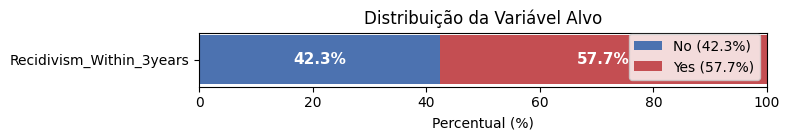

In [49]:
# Distribuição da variável alvo
print("Distribuição de Recidivism_Within_3years:")
print(df['Recidivism_Within_3years'].value_counts())
print("\nPercentual:")
print(df['Recidivism_Within_3years'].value_counts(normalize=True) * 100)

# Plot barra dividida (stacked) — azul para No, vermelho para Yes
counts = df['Recidivism_Within_3years'].value_counts(normalize=True) * 100
no_pct = counts.get('No', 0)
yes_pct = counts.get('Yes', 0)

plt.figure(figsize=(8, 1.5))
plt.barh(0, no_pct, color='#4C72B0', label=f'No ({no_pct:.1f}%)')
plt.barh(0, yes_pct, left=no_pct, color='#C44E52', label=f'Yes ({yes_pct:.1f}%)')
plt.text(no_pct / 2, 0, f'{no_pct:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=11)
plt.text(no_pct + yes_pct / 2, 0, f'{yes_pct:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=11)
plt.yticks([0], ['Recidivism_Within_3years'])
plt.xlabel('Percentual (%)')
plt.title('Distribuição da Variável Alvo')
plt.legend(loc='lower right')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [32]:
# Verificar duplicatas
duplicates = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicates}")

# Tipos de dados únicos para colunas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nColunas categóricas e seus valores únicos:")
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} valores únicos")
    if df[col].nunique() <= 10:
        print(f"  Valores: {df[col].unique()}")

Número de linhas duplicadas: 0

Colunas categóricas e seus valores únicos:
Gender: 2 valores únicos
  Valores: <StringArray>
['M', 'F']
Length: 2, dtype: str
Race: 2 valores únicos
  Valores: <StringArray>
['BLACK', 'WHITE']
Length: 2, dtype: str
Age_at_Release: 7 valores únicos
  Valores: <StringArray>
['43-47', '33-37', '48 or older', '38-42', '18-22', '23-27', '28-32']
Length: 7, dtype: str
Gang_Affiliated: 2 valores únicos
  Valores: <StringArray>
['No', nan, 'Yes']
Length: 3, dtype: str
Supervision_Level_First: 3 valores únicos
  Valores: <StringArray>
['Standard', 'Specialized', 'High', nan]
Length: 4, dtype: str
Education_Level: 3 valores únicos
  Valores: <StringArray>
['At least some college', 'Less than HS diploma', 'High School Diploma']
Length: 3, dtype: str
Dependents: 4 valores únicos
  Valores: <StringArray>
['3 or more', '1', '0', '2']
Length: 4, dtype: str
Prison_Offense: 5 valores únicos
  Valores: <StringArray>
['Drug', 'Violent/Non-Sex', 'Property', nan, 'Other', 'V

/var/folders/4m/gng0hp257dgclj7dzphkt54c0000gn/T/ipykernel_998/1589779261.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


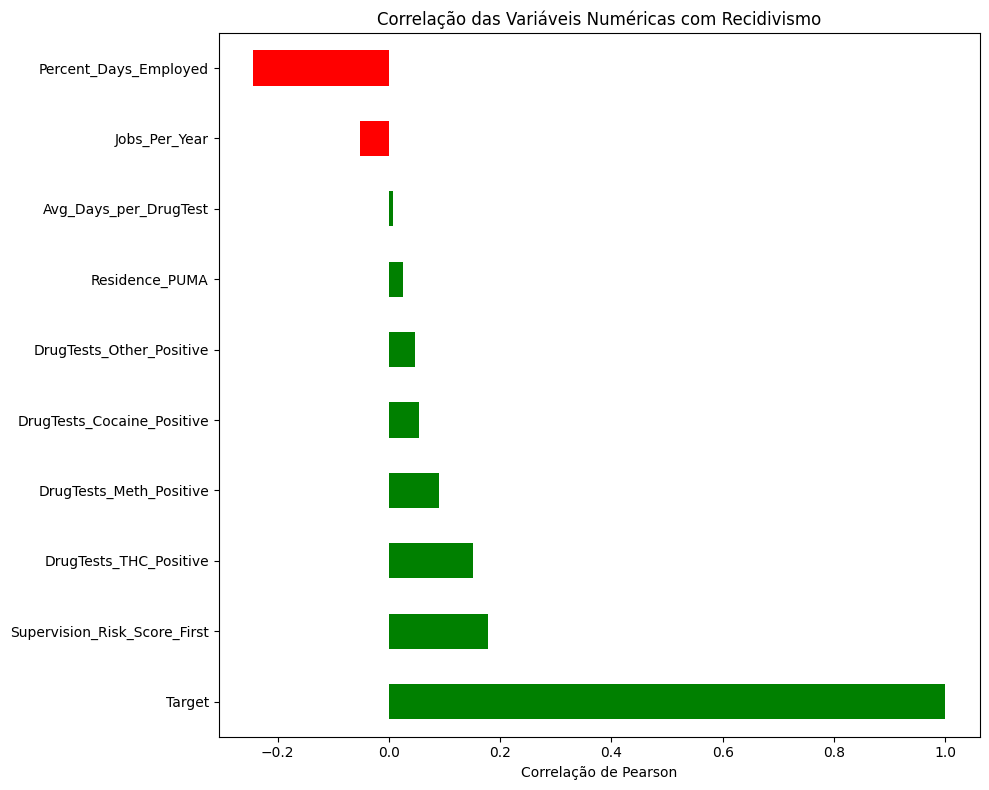


Correlações com o Target:
Target                          1.000000
Supervision_Risk_Score_First    0.178494
DrugTests_THC_Positive          0.151941
DrugTests_Meth_Positive         0.090264
DrugTests_Cocaine_Positive      0.053806
DrugTests_Other_Positive        0.047925
Residence_PUMA                  0.025203
Avg_Days_per_DrugTest           0.007615
Jobs_Per_Year                  -0.051185
Percent_Days_Employed          -0.243669
dtype: float64


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Converter target para numérico para análise de correlação
df['Target'] = df['Recidivism_Within_3years'].map({'Yes': 1, 'No': 0})

# Colunas numéricas (excluir ID, Training_Sample e colunas de leakage)
leak_cols = ['ID', 'Training_Sample', 'Recidivism_Arrest_Year1', 'Recidivism_Arrest_Year2', 'Recidivism_Arrest_Year3']
num_cols = df.select_dtypes(include=[np.number]).columns.difference(leak_cols)

# Correlação das variáveis numéricas com o Target
corr_target = df[num_cols].corrwith(df['Target']).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
corr_target.plot(kind='barh', color=['green' if x > 0 else 'red' for x in corr_target])
plt.title('Correlação das Variáveis Numéricas com Recidivismo')
plt.xlabel('Correlação de Pearson')
plt.tight_layout()
plt.show()

print("\nCorrelações com o Target:")
print(corr_target)

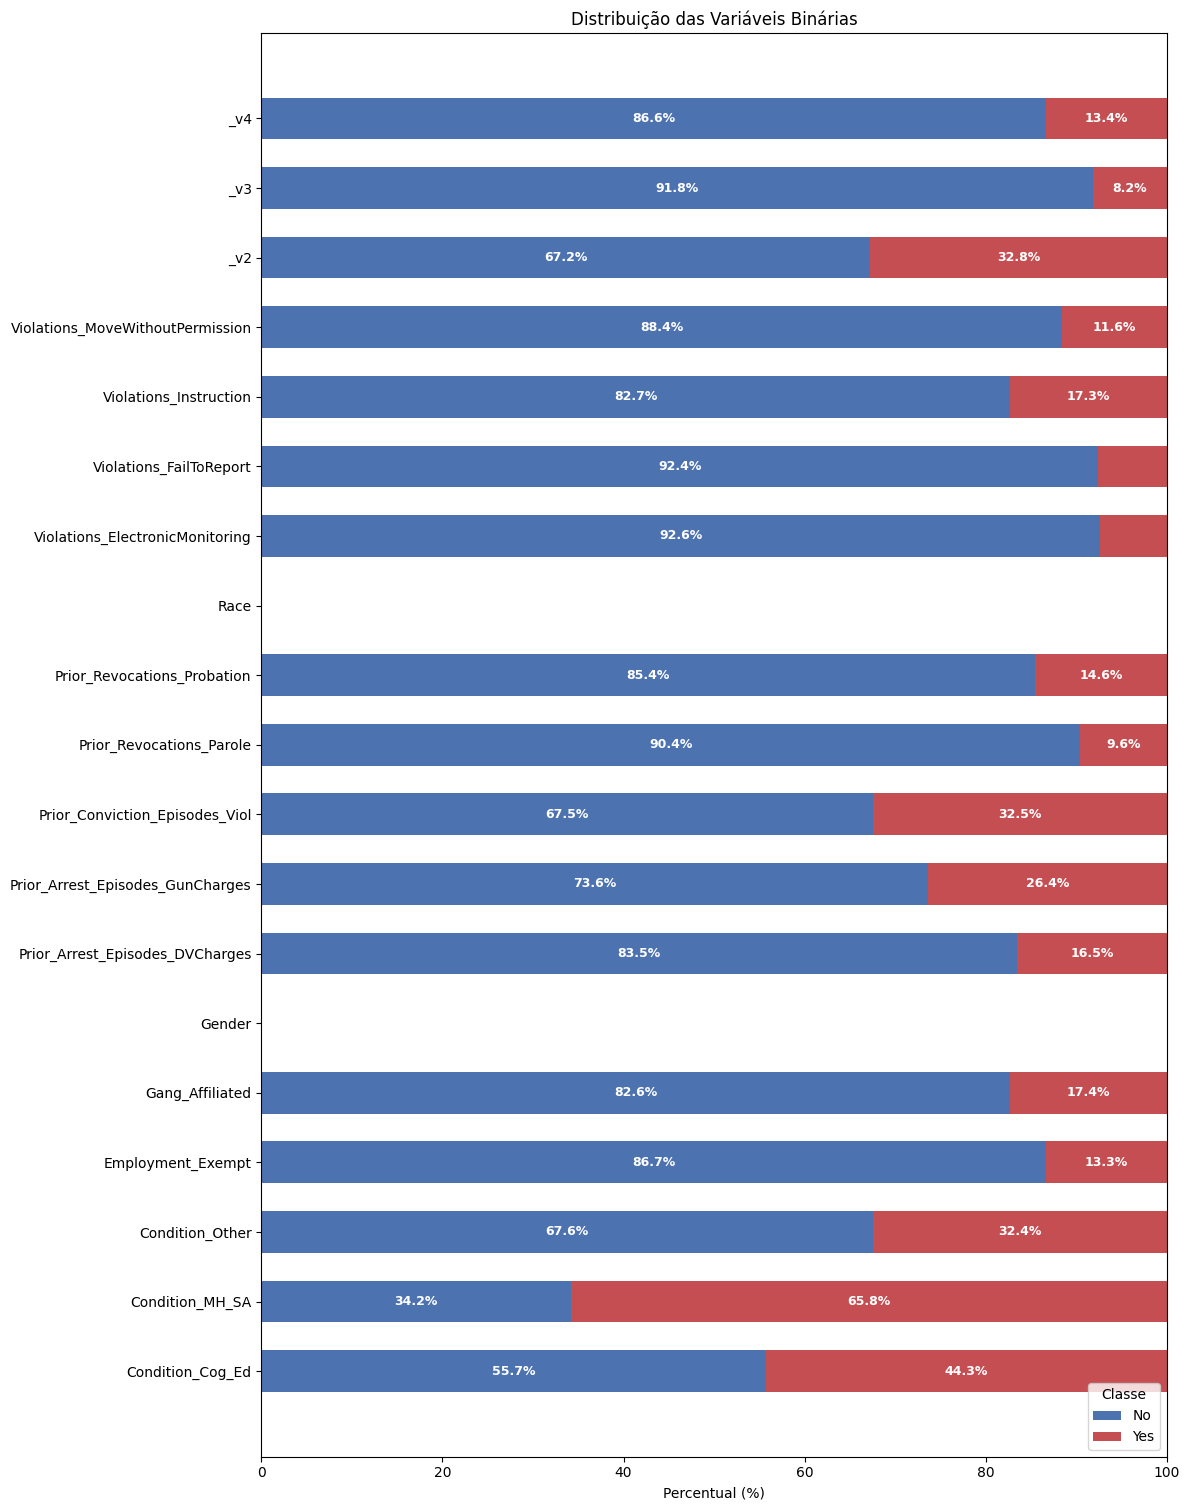

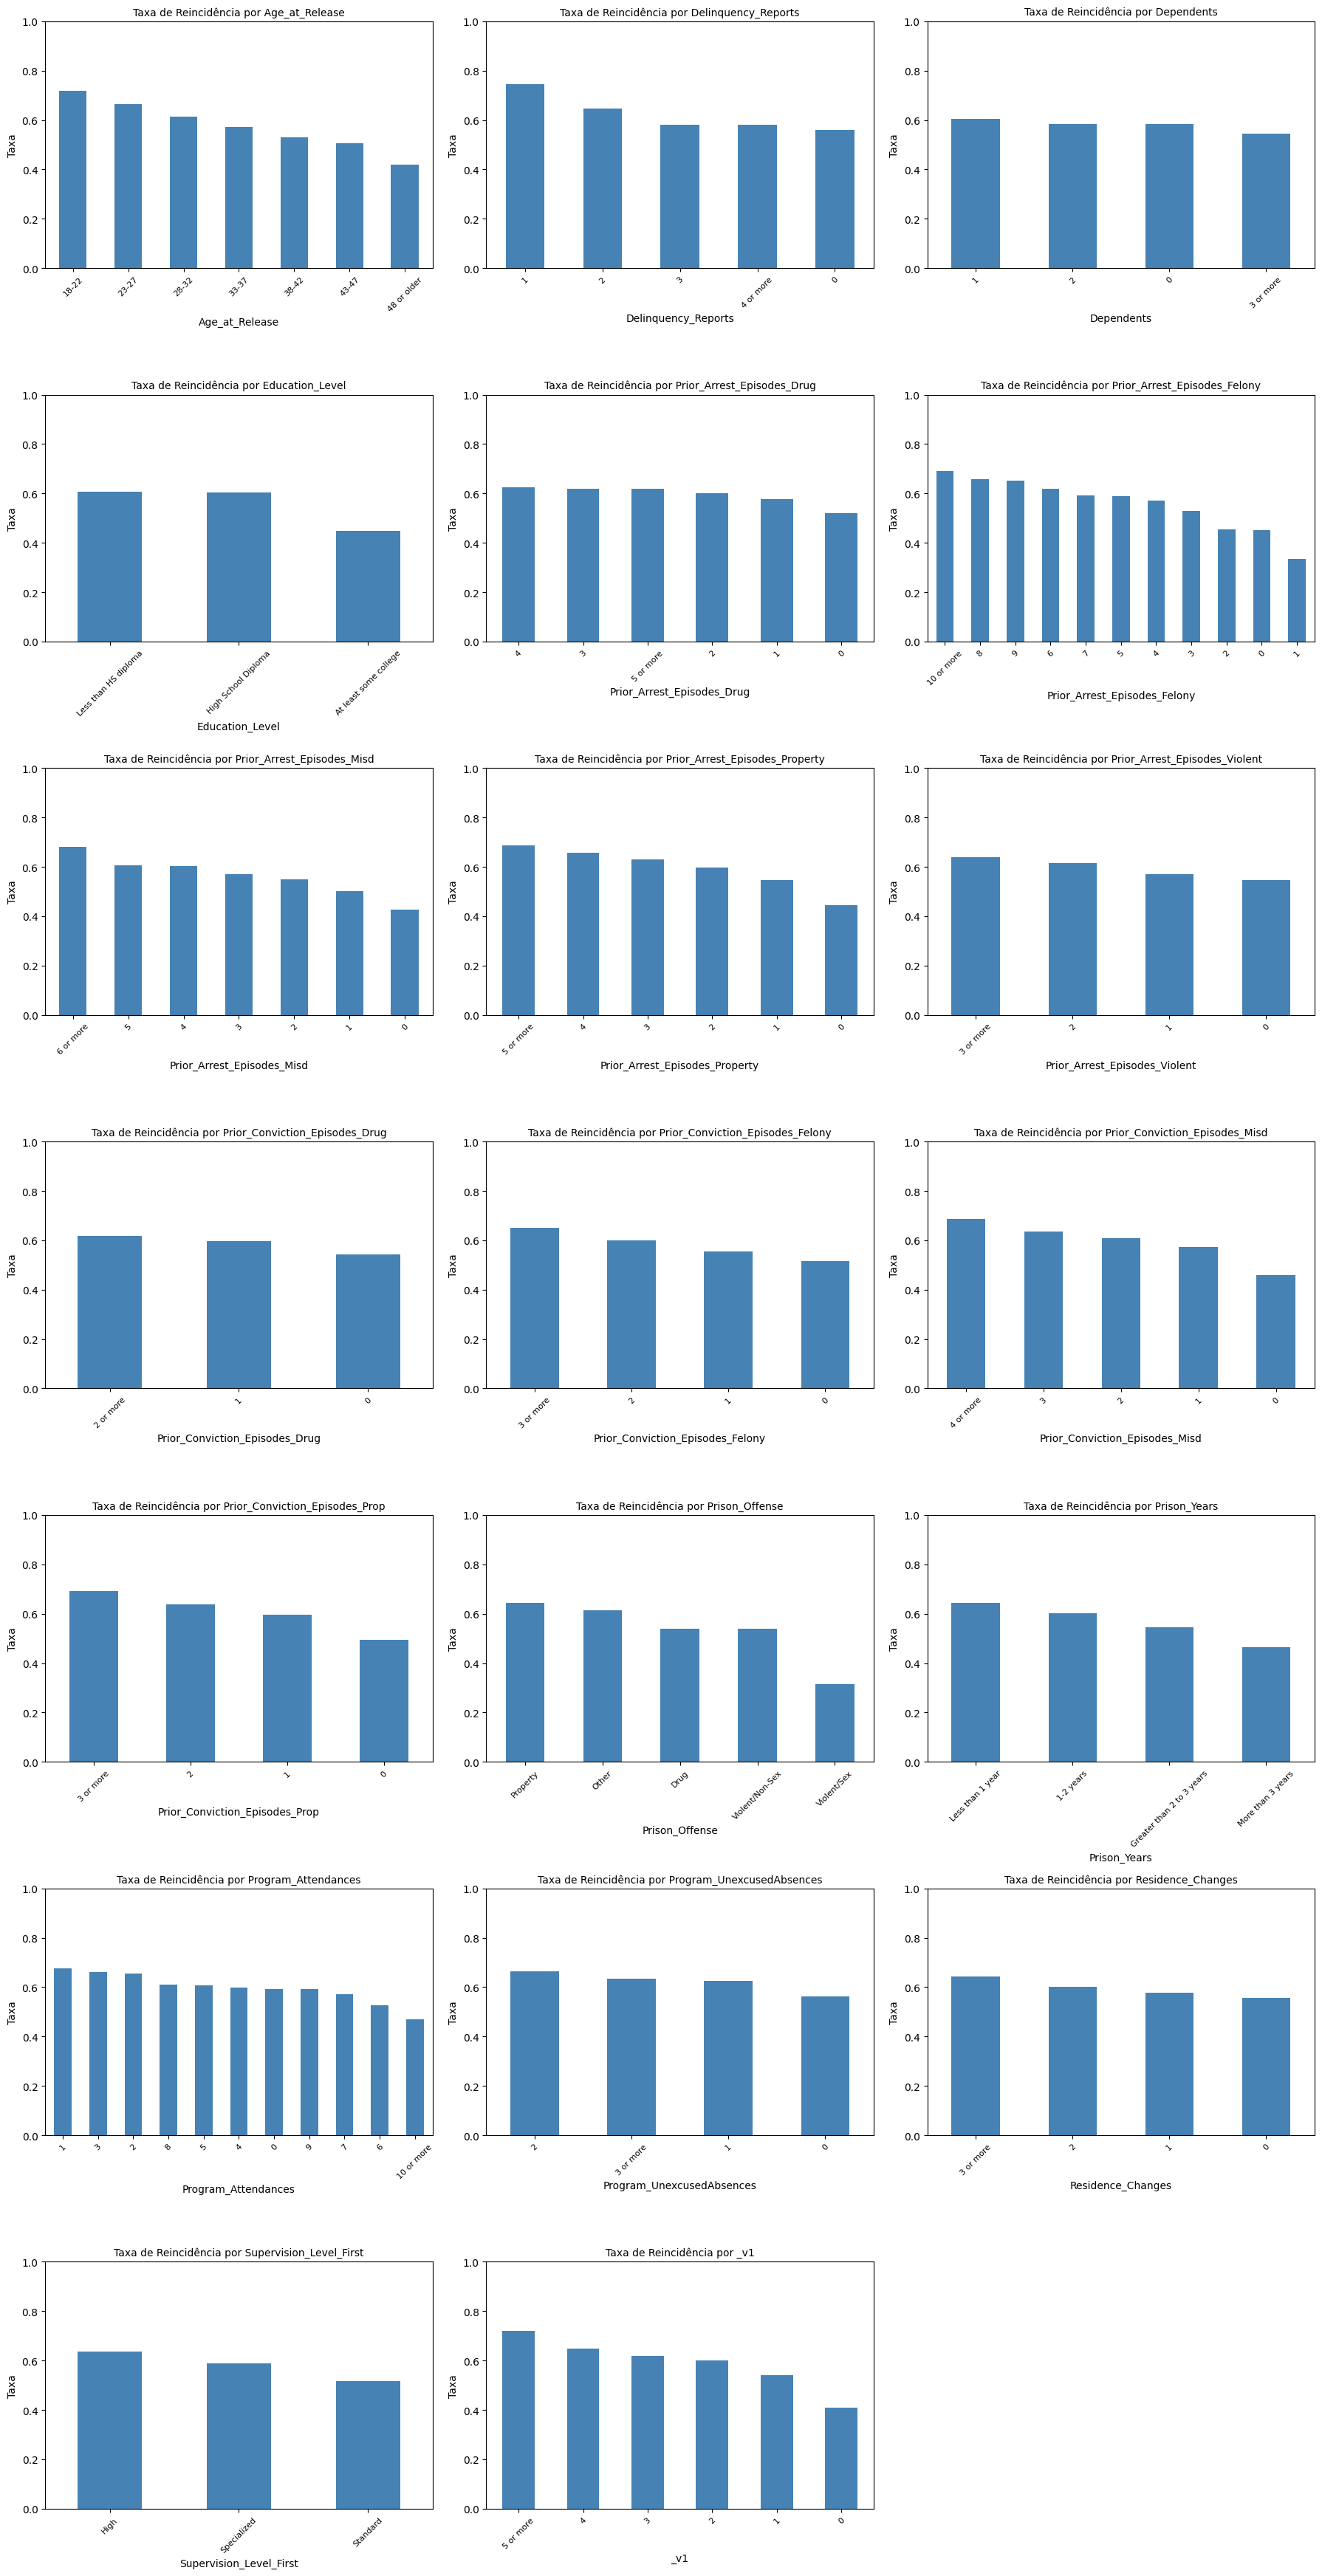

In [48]:
# Taxa de reincidência por variável categórica
cat_cols = df.select_dtypes(include=['object', 'string']).columns.difference(
    ['Recidivism_Within_3years', 'Recidivism_Arrest_Year1', 'Recidivism_Arrest_Year2', 'Recidivism_Arrest_Year3']
)

# Separar variáveis binárias das não-binárias
binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
non_binary_cols = [col for col in cat_cols if df[col].nunique() > 2]

# --- Gráfico único para variáveis binárias: barra dividida (stacked) ---
if binary_cols:
    # Para cada variável binária, calcular percentual de No e Yes
    no_pcts = []
    yes_pcts = []
    for col in binary_cols:
        counts = df[col].value_counts(normalize=True) * 100
        no_pcts.append(counts.get('No', counts.get(0, 0)))
        yes_pcts.append(counts.get('Yes', counts.get(1, 0)))

    y_pos = np.arange(len(binary_cols))
    bar_height = 0.6

    plt.figure(figsize=(12, max(4, len(binary_cols) * 0.8)))

    # Barra azul (No) como base
    bars_no = plt.barh(y_pos, no_pcts, height=bar_height, color='#4C72B0', label='No')
    # Barra vermelha (Yes) empilhada à direita
    bars_yes = plt.barh(y_pos, yes_pcts, height=bar_height, left=no_pcts, color='#C44E52', label='Yes')

    # Anotar percentuais dentro das barras
    for i, (no, yes) in enumerate(zip(no_pcts, yes_pcts)):
        if no > 8:
            plt.text(no / 2, y_pos[i], f'{no:.1f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        if yes > 8:
            plt.text(no + yes / 2, y_pos[i], f'{yes:.1f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    plt.yticks(y_pos, binary_cols)
    plt.xlabel('Percentual (%)')
    plt.title('Distribuição das Variáveis Binárias')
    plt.legend(title='Classe', loc='lower right')
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()

# --- Gráficos individuais para variáveis não-binárias ---
if non_binary_cols:
    n_plots = len(non_binary_cols)
    n_cols_grid = 3
    n_rows = (n_plots + n_cols_grid - 1) // n_cols_grid
    fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(18, 5 * n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    for i, col in enumerate(non_binary_cols):
        rate = df.groupby(col)['Target'].mean().sort_values(ascending=False)
        rate.plot(kind='bar', ax=axes[i], color='steelblue')
        axes[i].set_title(f'Taxa de Reincidência por {col}', fontsize=10)
        axes[i].set_ylabel('Taxa')
        axes[i].set_ylim(0, 1)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

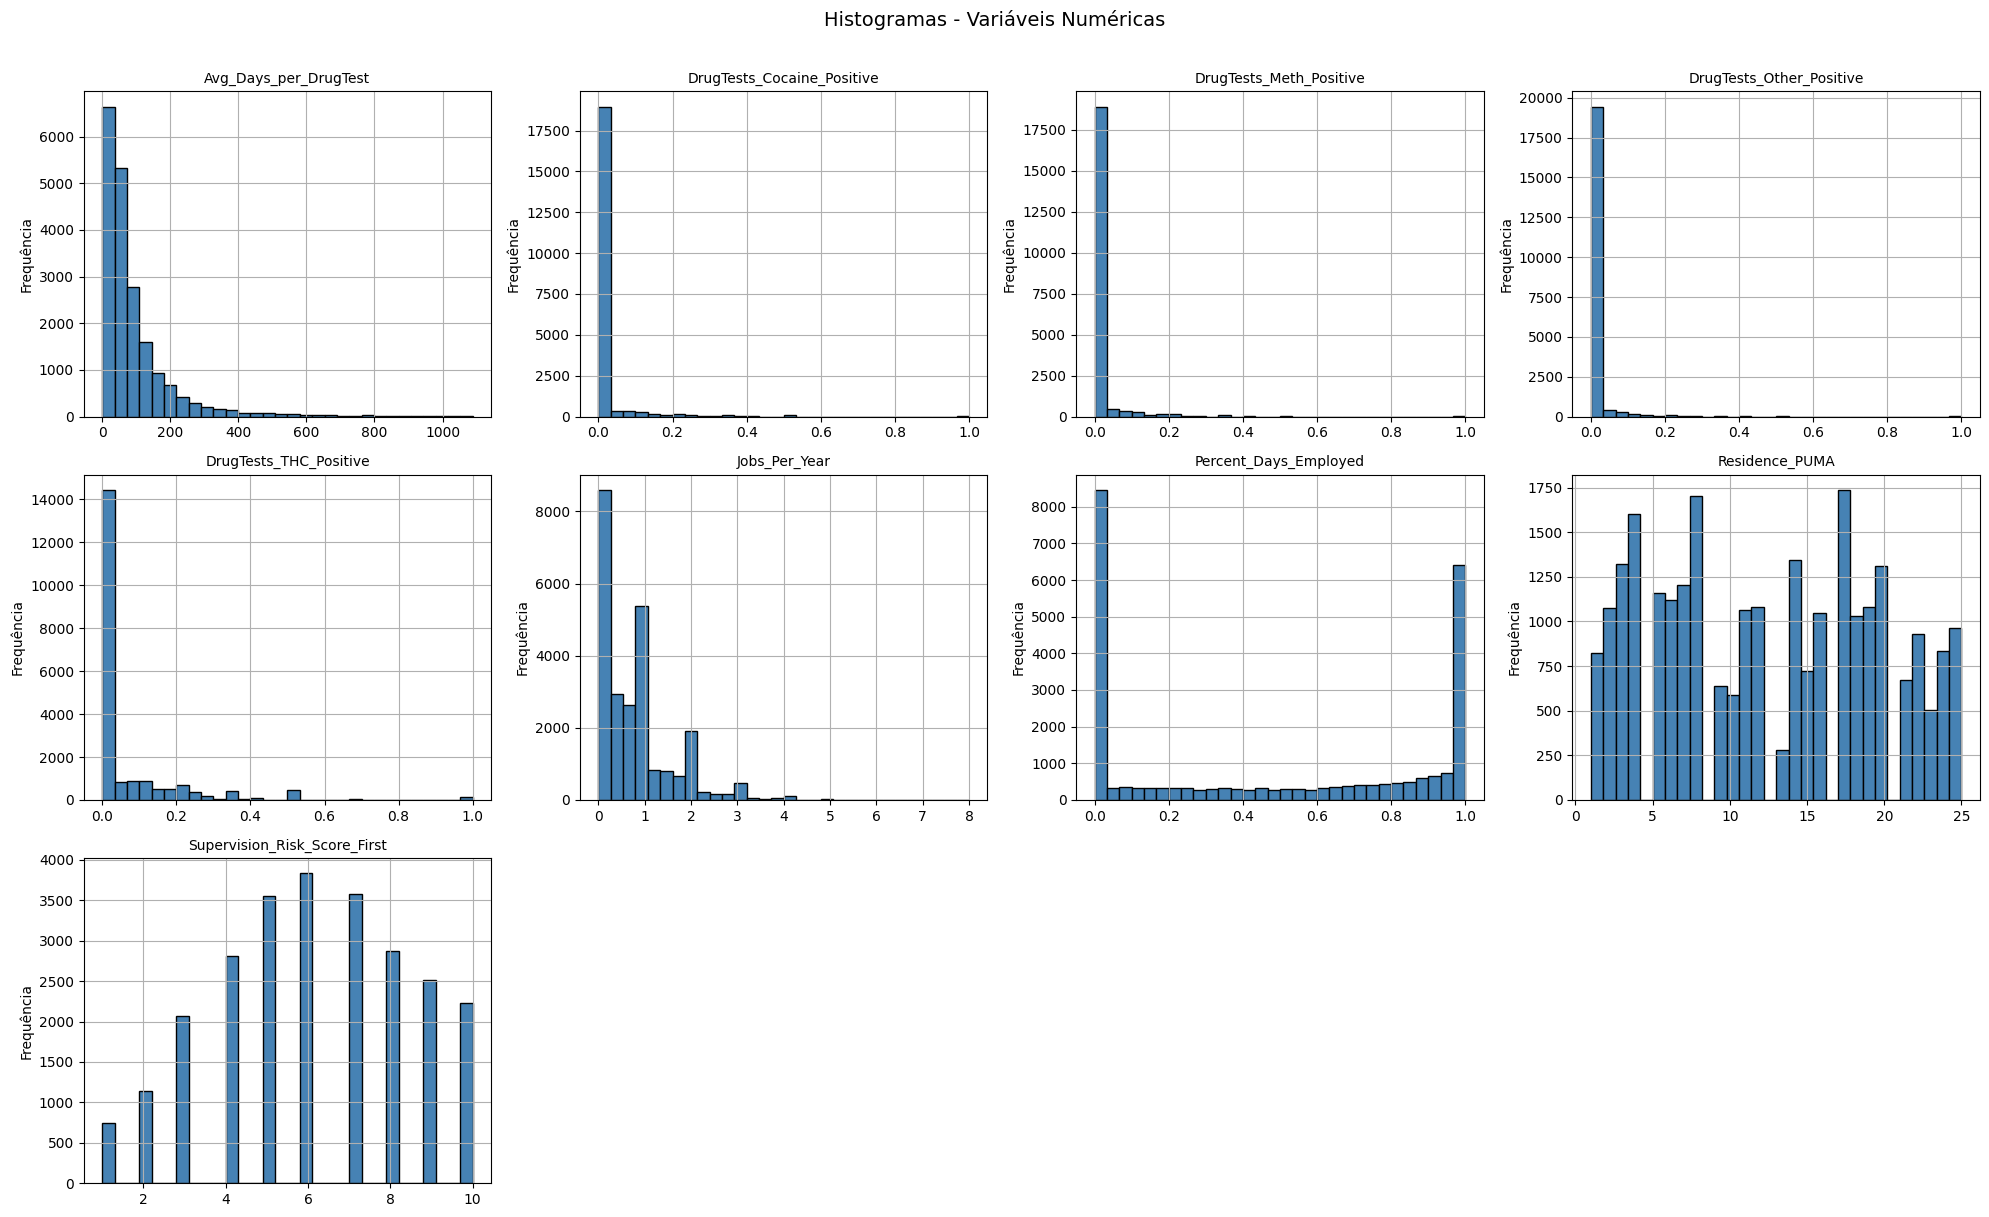

In [36]:
# Histogramas de todas as variáveis numéricas
num_hist_cols = df.select_dtypes(include=[np.number]).columns.difference(['ID', 'Training_Sample', 'Target'])
n_plots = len(num_hist_cols)
n_cols_grid = 4
n_rows_grid = (n_plots + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, 4 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(num_hist_cols):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frequência')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas - Variáveis Numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

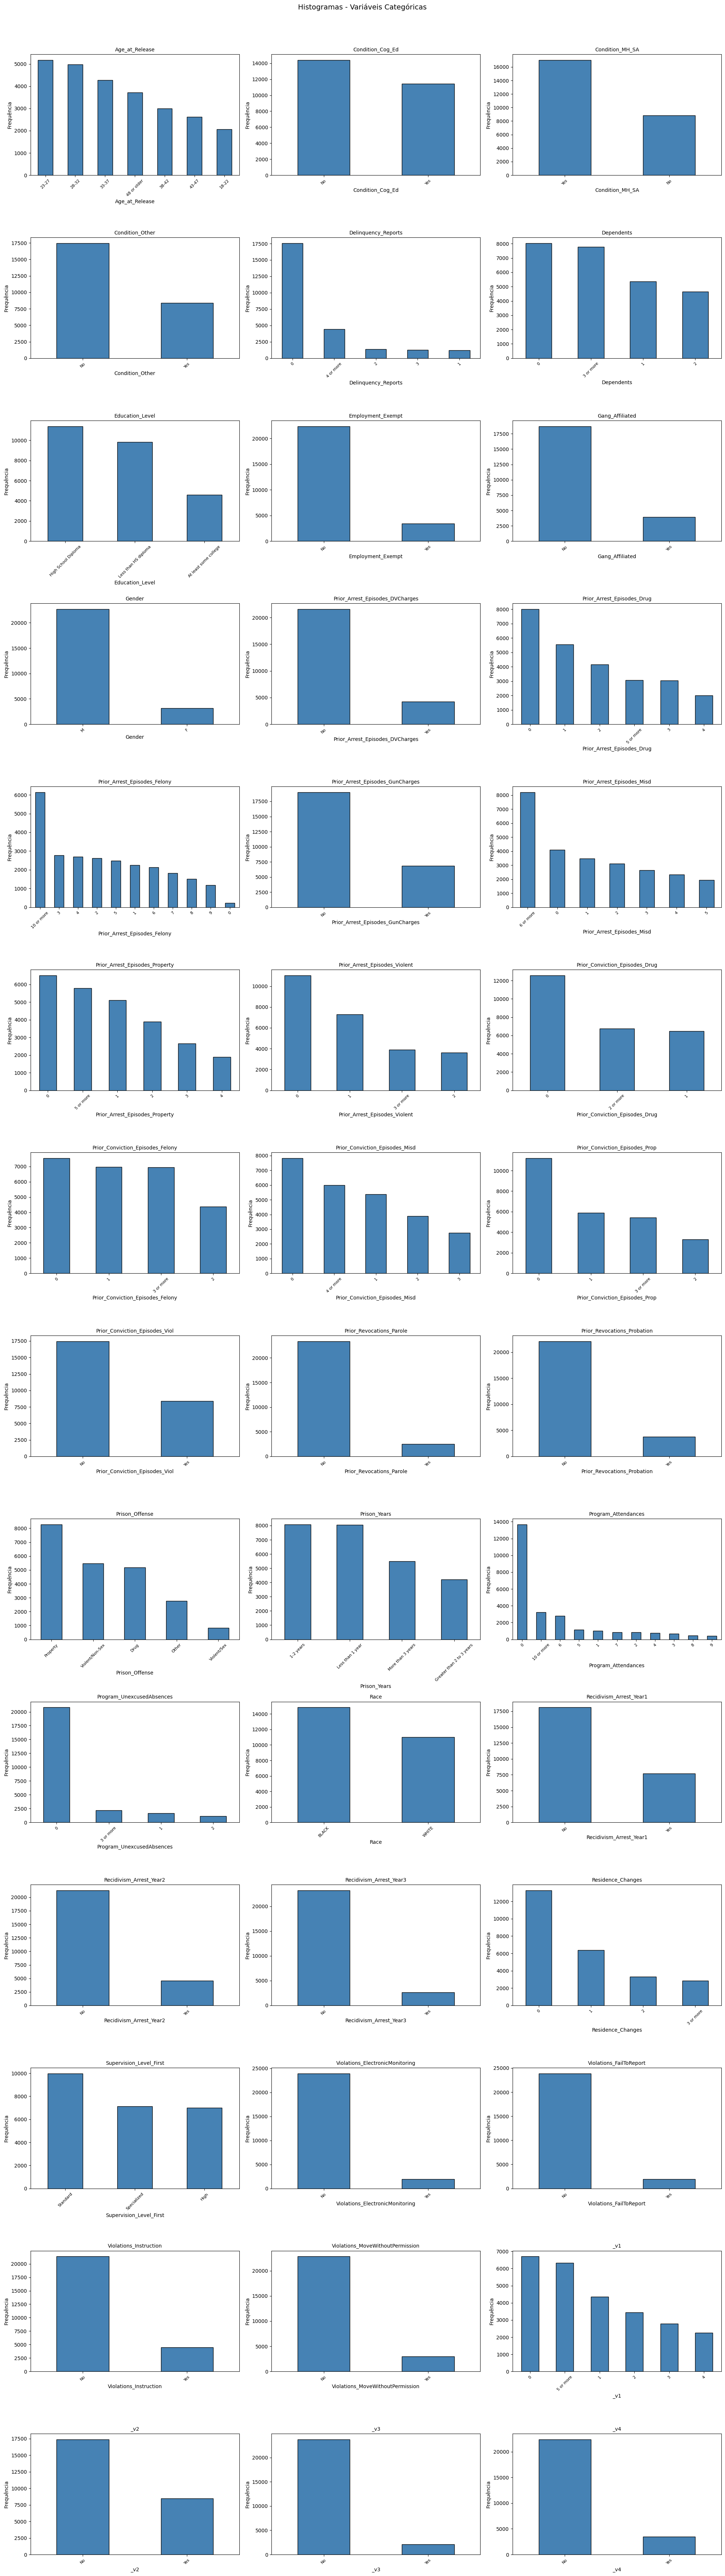

In [37]:
# Histogramas de todas as variáveis categóricas
cat_hist_cols = df.select_dtypes(include=['object', 'string']).columns.difference(['Recidivism_Within_3years'])
n_plots = len(cat_hist_cols)
n_cols_grid = 3
n_rows_grid = (n_plots + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, 5 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(cat_hist_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frequência')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas - Variáveis Categóricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

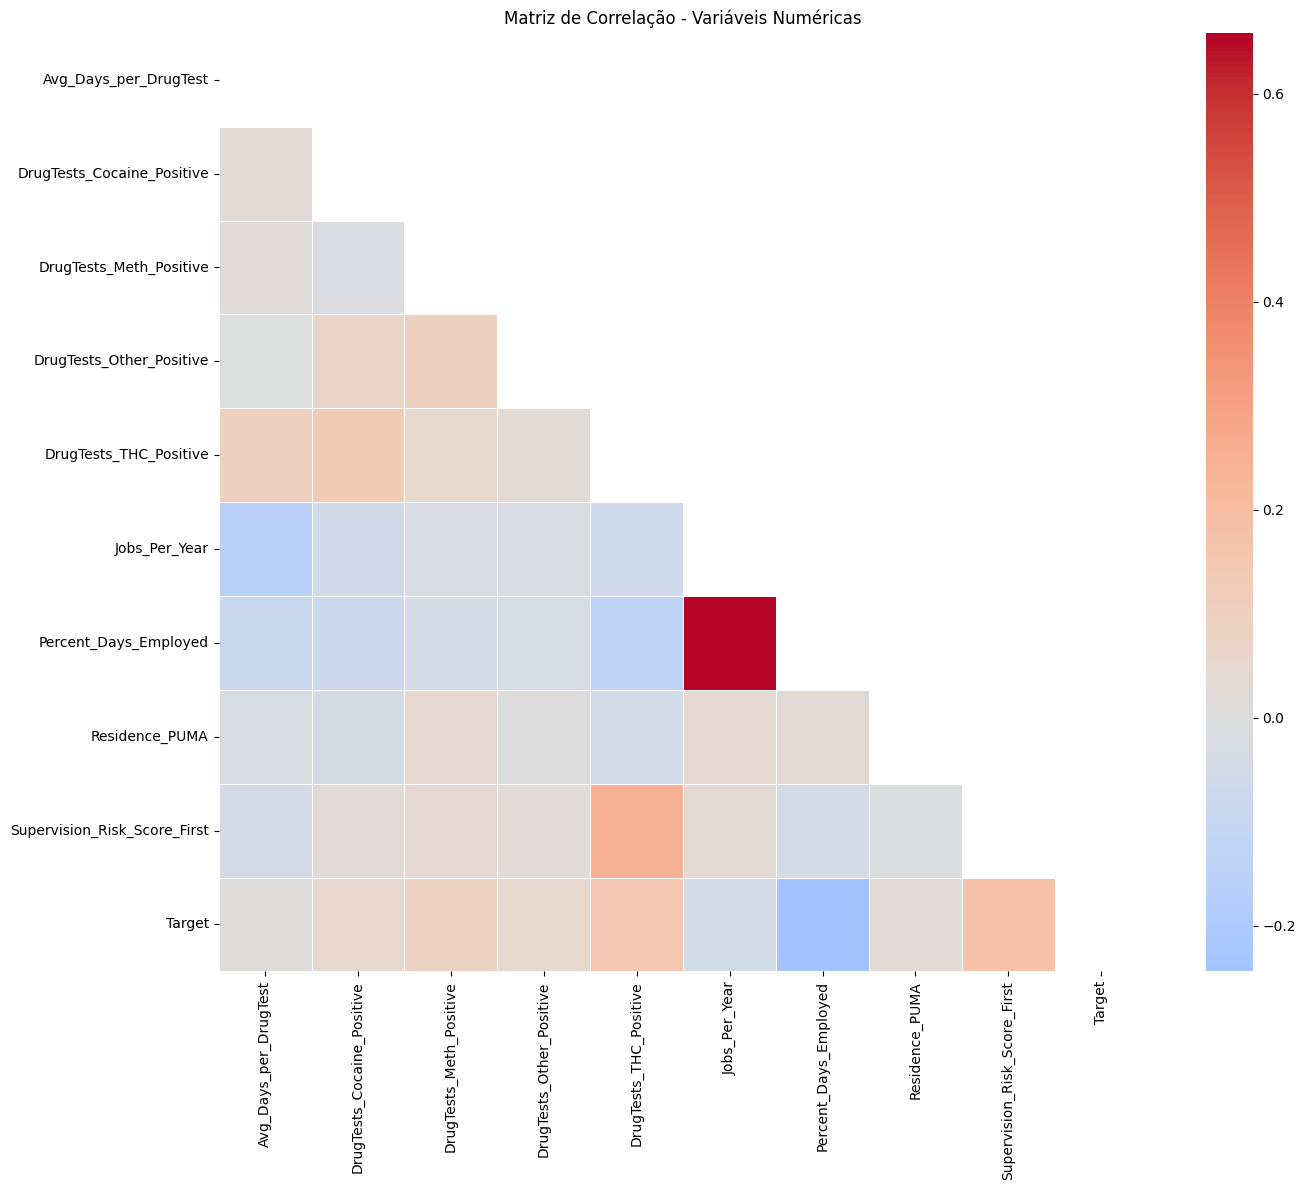

In [34]:
# Matriz de correlação das variáveis numéricas
plt.figure(figsize=(14, 12))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.tight_layout()
plt.show()

# 3. Preparação dos Dados (Data Preparation)

Seleciona, limpa, transforma e formata os dados para modelagem. Esta etapa costuma consumir a maior parte do tempo do projeto (60-70%).

In [38]:
# 3.1 Remover colunas irrelevantes e de data leakage
drop_cols = [
    'ID',                        # Identificador, sem valor preditivo
    'Recidivism_Arrest_Year1',   # Data leakage - informação do futuro
    'Recidivism_Arrest_Year2',   # Data leakage
    'Recidivism_Arrest_Year3',   # Data leakage
    '_v1', '_v2', '_v3', '_v4',  # Colunas sem nome claro
]

df_model = df.drop(columns=drop_cols + ['Recidivism_Within_3years', 'Target'])
print(f"Colunas removidas: {drop_cols}")
print(f"Shape após remoção: {df_model.shape}")
print(f"\nColunas restantes ({len(df_model.columns)}):")
print(df_model.columns.tolist())

Colunas removidas: ['ID', 'Recidivism_Arrest_Year1', 'Recidivism_Arrest_Year2', 'Recidivism_Arrest_Year3', '_v1', '_v2', '_v3', '_v4']
Shape após remoção: (25835, 45)

Colunas restantes (45):
['Gender', 'Race', 'Age_at_Release', 'Residence_PUMA', 'Gang_Affiliated', 'Supervision_Risk_Score_First', 'Supervision_Level_First', 'Education_Level', 'Dependents', 'Prison_Offense', 'Prison_Years', 'Prior_Arrest_Episodes_Felony', 'Prior_Arrest_Episodes_Misd', 'Prior_Arrest_Episodes_Violent', 'Prior_Arrest_Episodes_Property', 'Prior_Arrest_Episodes_Drug', 'Prior_Arrest_Episodes_DVCharges', 'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Felony', 'Prior_Conviction_Episodes_Misd', 'Prior_Conviction_Episodes_Viol', 'Prior_Conviction_Episodes_Prop', 'Prior_Conviction_Episodes_Drug', 'Prior_Revocations_Parole', 'Prior_Revocations_Probation', 'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other', 'Violations_ElectronicMonitoring', 'Violations_Instruction', 'Violations_FailToReport', '

In [39]:
# 3.2 Separar train/test usando a coluna Training_Sample (antes de qualquer transformação)
train_mask = df['Training_Sample'] == 1
test_mask = df['Training_Sample'] == 0

X_train = df_model[train_mask].drop(columns=['Training_Sample'])
X_test = df_model[test_mask].drop(columns=['Training_Sample'])
y_train = df['Target'][train_mask]
y_test = df['Target'][test_mask]

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nDistribuição do target no treino:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribuição do target no teste:")
print(y_test.value_counts(normalize=True).round(3))

Treino: 18028 amostras
Teste:  7807 amostras

Distribuição do target no treino:
Target
1    0.578
0    0.422
Name: proportion, dtype: float64

Distribuição do target no teste:
Target
1    0.574
0    0.426
Name: proportion, dtype: float64


In [40]:
# 3.3 Identificar colunas categóricas e numéricas
cat_features = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Variáveis categóricas ({len(cat_features)}): {cat_features}")
print(f"\nVariáveis numéricas ({len(num_features)}): {num_features}")

Variáveis categóricas (35): ['Gender', 'Race', 'Age_at_Release', 'Gang_Affiliated', 'Supervision_Level_First', 'Education_Level', 'Dependents', 'Prison_Offense', 'Prison_Years', 'Prior_Arrest_Episodes_Felony', 'Prior_Arrest_Episodes_Misd', 'Prior_Arrest_Episodes_Violent', 'Prior_Arrest_Episodes_Property', 'Prior_Arrest_Episodes_Drug', 'Prior_Arrest_Episodes_DVCharges', 'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Felony', 'Prior_Conviction_Episodes_Misd', 'Prior_Conviction_Episodes_Viol', 'Prior_Conviction_Episodes_Prop', 'Prior_Conviction_Episodes_Drug', 'Prior_Revocations_Parole', 'Prior_Revocations_Probation', 'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other', 'Violations_ElectronicMonitoring', 'Violations_Instruction', 'Violations_FailToReport', 'Violations_MoveWithoutPermission', 'Delinquency_Reports', 'Program_Attendances', 'Program_UnexcusedAbsences', 'Residence_Changes', 'Employment_Exempt']

Variáveis numéricas (9): ['Residence_PUMA', 'Supervision_Risk

In [41]:
# 3.4 Tratar valores missing e encoding com Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Pipeline para variáveis numéricas: imputar com mediana + padronizar
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variáveis categóricas: imputar com moda + one-hot encoding
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinar pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Fit no treino, transform em treino e teste
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Obter nomes das features após transformação
cat_encoded_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_features)
feature_names = list(num_features) + list(cat_encoded_names)

print(f"Features após pré-processamento: {X_train_processed.shape[1]}")
print(f"Treino: {X_train_processed.shape}")
print(f"Teste:  {X_test_processed.shape}")
print(f"\nValores missing no treino processado: {np.isnan(X_train_processed).sum()}")
print(f"Valores missing no teste processado: {np.isnan(X_test_processed).sum()}")

Features após pré-processamento: 141
Treino: (18028, 141)
Teste:  (7807, 141)

Valores missing no treino processado: 0
Valores missing no teste processado: 0


# 4. Modelagem (Modeling)

Aplica algoritmos de machine learning (técnicas de modelagem) aos dados preparados e ajusta os parâmetros para obter o melhor desempenho.

In [42]:
# 4.1 Árvore de Decisão
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=10)
model.fit(X_train_processed, y_train)

# Predições
y_pred = model.predict(X_test_processed)
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

print("Modelo treinado com sucesso!")
print(f"Acurácia no treino: {model.score(X_train_processed, y_train):.4f}")
print(f"Acurácia no teste:  {model.score(X_test_processed, y_test):.4f}")

Modelo treinado com sucesso!
Acurácia no treino: 0.6984
Acurácia no teste:  0.6898


# 5. Avaliação (Evaluation)

Verifica se o modelo construído atende às metas de negócio estabelecidas na primeira etapa.

Classification Report:
                     precision    recall  f1-score   support

Não Reincidente (0)       0.74      0.42      0.54      3324
    Reincidente (1)       0.67      0.89      0.77      4483

           accuracy                           0.69      7807
          macro avg       0.71      0.66      0.65      7807
       weighted avg       0.70      0.69      0.67      7807



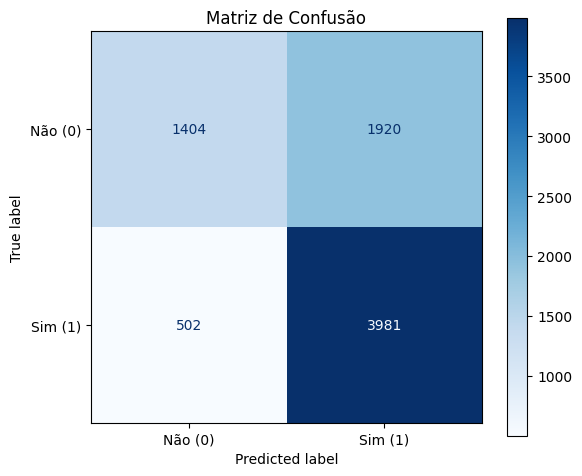

In [43]:
# 5.1 Matriz de Confusão e Classification Report
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Não Reincidente (0)', 'Reincidente (1)']))

# Plot da Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Não (0)', 'Sim (1)'], ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusão')
plt.tight_layout()
plt.show()

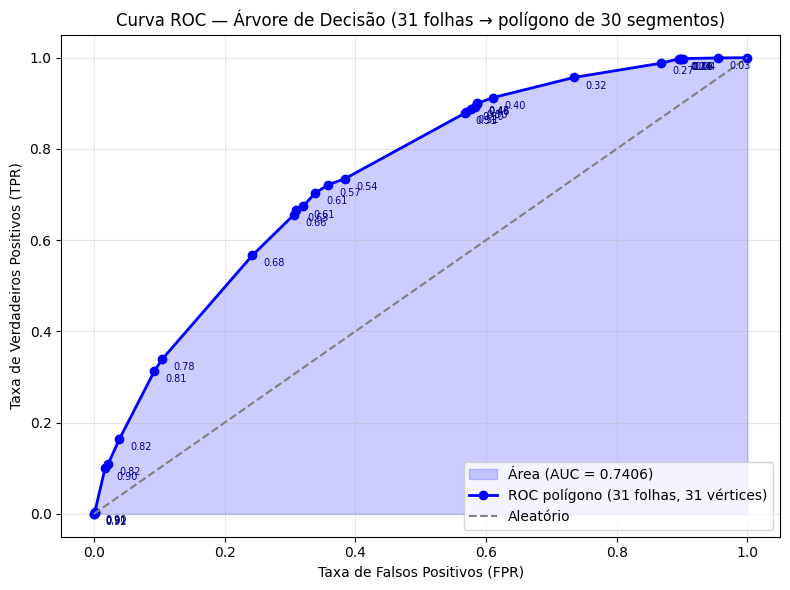

AUC Score: 0.7406
Número de folhas: 31
Probabilidades únicas (limiares das folhas): [0.         0.03017241 0.04347826 0.05555556 0.1        0.24033149
 0.27408514 0.31977946 0.39747634 0.45454545 0.46067416 0.5
 0.5034965  0.50666667 0.5129672  0.53703704 0.57058824 0.60626398
 0.60833333 0.63265306 0.65776173 0.68221321 0.77948718 0.80651434
 0.81793842 0.82432432 0.89867841 0.9        0.90909091 0.91666667]
Vértices do polígono ROC: 31 pontos


In [44]:
# 5.2 Curva ROC e AUC — Árvore de Decisão (polígono com n-1 folhas)
from sklearn.metrics import roc_auc_score
import numpy as np

# Número de folhas da árvore
n_leaves = model.get_n_leaves()

# Probabilidades únicas (cada folha gera um valor distinto de P(classe=1))
leaf_probas = np.unique(y_pred_proba)

# Construir a curva ROC manualmente a partir dos limiares das folhas
# Ordenamos os limiares de forma decrescente (do mais "positivo" ao menos "positivo")
thresholds_sorted = np.sort(leaf_probas)[::-1]

# Pontos da curva: começa em (0,0) — nenhum classificado como positivo
roc_points = [(0.0, 0.0)]

for t in thresholds_sorted:
    # Classificar como positivo todos com prob >= t
    y_hat = (y_pred_proba >= t).astype(int)
    tp = np.sum((y_hat == 1) & (y_test.values == 1))
    fp = np.sum((y_hat == 1) & (y_test.values == 0))
    fn = np.sum((y_hat == 0) & (y_test.values == 1))
    tn = np.sum((y_hat == 0) & (y_test.values == 0))
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    roc_points.append((fpr_val, tpr_val))

# Garantir que termina em (1,1)
if roc_points[-1] != (1.0, 1.0):
    roc_points.append((1.0, 1.0))

fpr_poly = [p[0] for p in roc_points]
tpr_poly = [p[1] for p in roc_points]

auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot do polígono ROC
plt.figure(figsize=(8, 6))
plt.fill_between(fpr_poly, tpr_poly, alpha=0.2, color='blue', step=None,
                 label=f'Área (AUC = {auc_score:.4f})')
plt.plot(fpr_poly, tpr_poly, color='blue', lw=2, marker='o', markersize=6,
         label=f'ROC polígono ({n_leaves} folhas, {len(roc_points)} vértices)')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório')

# Anotar os vértices com os limiares
for i, (x, y) in enumerate(roc_points[1:-1], start=0):
    plt.annotate(f'{thresholds_sorted[i]:.2f}', (x, y),
                 textcoords="offset points", xytext=(8, -8), fontsize=7, color='darkblue')

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title(f'Curva ROC — Árvore de Decisão ({n_leaves} folhas → polígono de {n_leaves - 1} segmentos)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")
print(f"Número de folhas: {n_leaves}")
print(f"Probabilidades únicas (limiares das folhas): {np.sort(leaf_probas)}")
print(f"Vértices do polígono ROC: {len(roc_points)} pontos")

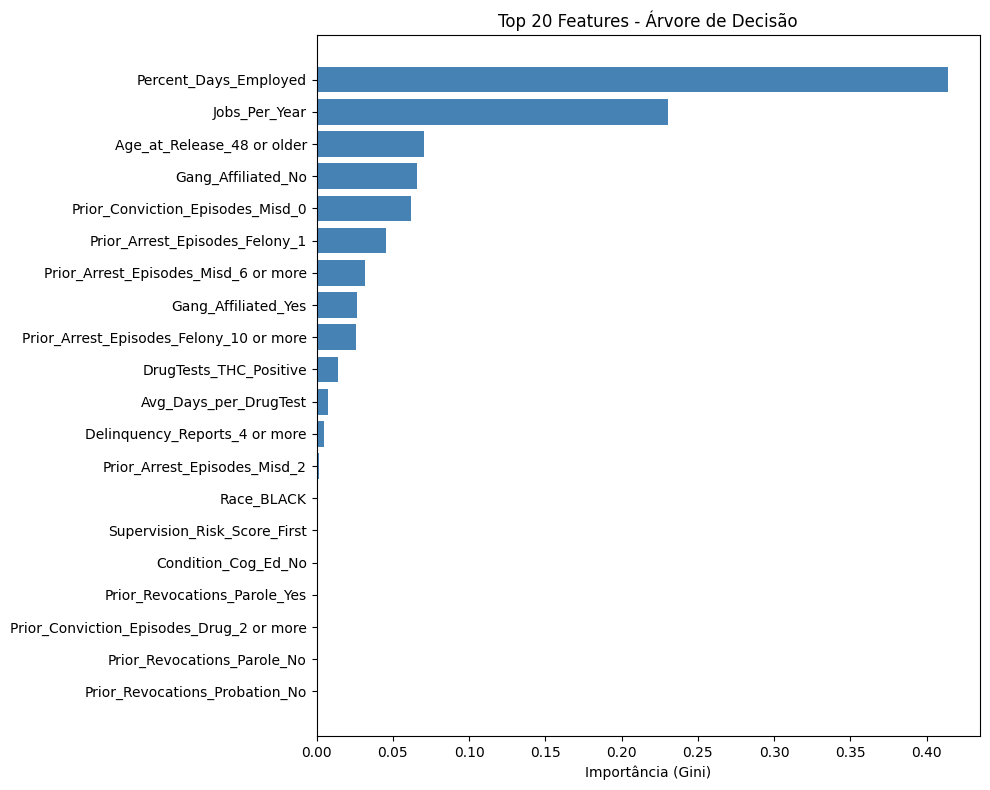

In [45]:
# 5.3 Importância das Features (Árvore de Decisão)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importância': model.feature_importances_
}).sort_values('Importância', ascending=False)

# Top 20 features mais importantes
top_features = importance_df.head(20).sort_values('Importância', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'], top_features['Importância'], color='steelblue')
plt.xlabel('Importância (Gini)')
plt.title('Top 20 Features - Árvore de Decisão')
plt.tight_layout()
plt.show()

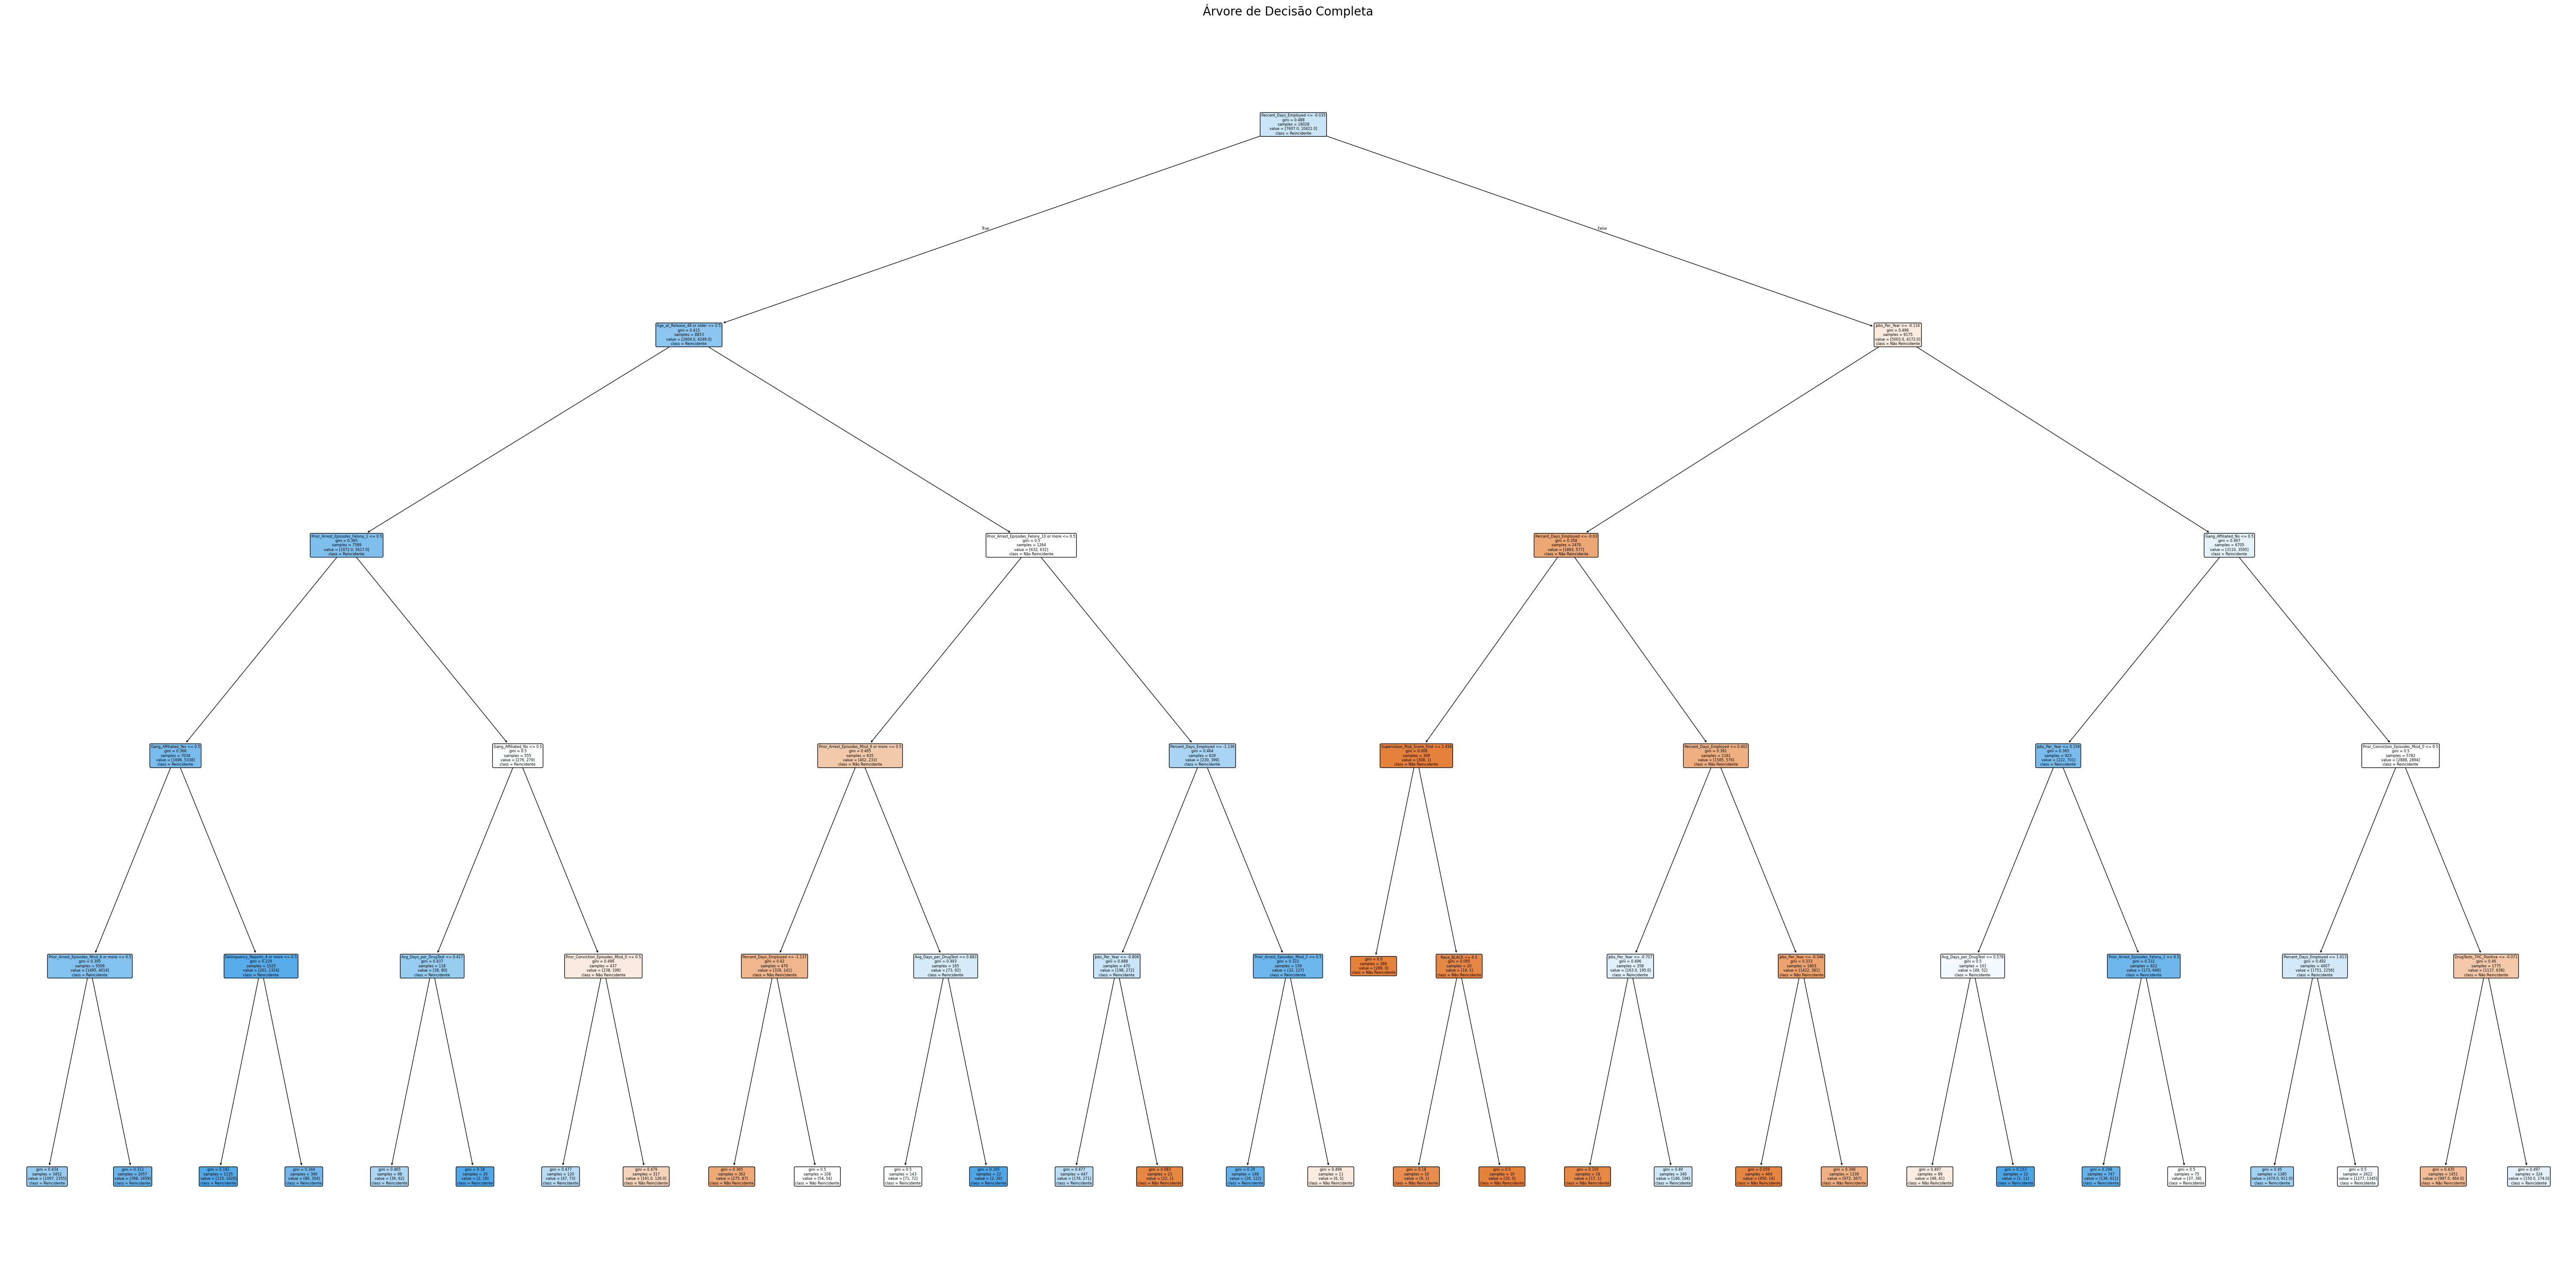

In [46]:
# 5.4 Visualização da Árvore de Decisão Completa
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(60, 30))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=['Não Reincidente', 'Reincidente'],
    filled=True,
    rounded=True,
    fontsize=6,
    ax=ax
)
plt.title('Árvore de Decisão Completa', fontsize=20)
plt.tight_layout()
plt.show()

# 6. Implantação (Deployment)

Coloca o modelo em produção para uso prático, o que pode incluir a criação de relatórios, ferramentas ou APIs, além de monitorar seu desempenho.

In [47]:
# 6.1 Resumo do Modelo
print("=" * 60)
print("RESUMO DO PROJETO - PREDIÇÃO DE REINCIDÊNCIA CRIMINAL")
print("=" * 60)
print(f"\nModelo: Árvore de Decisão")
print(f"Total de amostras: {len(df)}")
print(f"Treino: {X_train_processed.shape[0]} | Teste: {X_test_processed.shape[0]}")
print(f"Features utilizadas: {X_train_processed.shape[1]}")
print(f"\nMétricas no conjunto de teste:")
print(f"  Acurácia: {model.score(X_test_processed, y_test):.4f}")
print(f"  AUC:      {auc_score:.4f}")
print(f"\nDistribuição real no teste:")
print(f"  Reincidentes:     {(y_test == 1).sum()} ({(y_test == 1).mean():.1%})")
print(f"  Não reincidentes: {(y_test == 0).sum()} ({(y_test == 0).mean():.1%})")
print(f"\nTop 10 features mais importantes:")
top10 = importance_df.head(10)
for _, row in top10.iterrows():
    print(f"  {row['Feature']}: {row['Importância']:.4f}")

RESUMO DO PROJETO - PREDIÇÃO DE REINCIDÊNCIA CRIMINAL

Modelo: Árvore de Decisão
Total de amostras: 25835
Treino: 18028 | Teste: 7807
Features utilizadas: 141

Métricas no conjunto de teste:
  Acurácia: 0.6898
  AUC:      0.7406

Distribuição real no teste:
  Reincidentes:     4483 (57.4%)
  Não reincidentes: 3324 (42.6%)

Top 10 features mais importantes:
  Percent_Days_Employed: 0.4143
  Jobs_Per_Year: 0.2306
  Age_at_Release_48 or older: 0.0706
  Gang_Affiliated_No: 0.0655
  Prior_Conviction_Episodes_Misd_0: 0.0620
  Prior_Arrest_Episodes_Felony_1: 0.0456
  Prior_Arrest_Episodes_Misd_6 or more: 0.0317
  Gang_Affiliated_Yes: 0.0263
  Prior_Arrest_Episodes_Felony_10 or more: 0.0255
  DrugTests_THC_Positive: 0.0141
